In [2]:
#!/usr/bin/env python3
import os, glob
import numpy as np
import libstempo as lt

# --------------------------
# CONSTANTS
# --------------------------
SOLAR2S = 4.925490947e-6
MPC2S   = 1.02927125e14
KPC2S   = 3.085677581e19 / 2.99792458e8
EPS     = np.deg2rad(23.439291111)

def ecl_to_equ(elong, elat):
    lam, beta = elong, elat
    sin_delta = np.sin(beta)*np.cos(EPS) + np.cos(beta)*np.sin(EPS)*np.sin(lam)
    delta = np.arcsin(sin_delta)
    y = np.sin(lam)*np.cos(EPS) - np.tan(beta)*np.sin(EPS)
    x = np.cos(lam)
    alpha = np.arctan2(y, x) % (2*np.pi)
    return alpha, delta

# --------------------------
# CW MODEL (same as your injection code)
# --------------------------
def cw_residuals(psr, gwtheta, gwphi, mc, dist, fgw, phase0, psi, inc,
                 pdist=1.0, pphase=None, psrTerm=True, evolve=True,
                 phase_approx=False, tref=0.0):

    mc   *= SOLAR2S
    dist *= MPC2S
    w0 = np.pi*fgw
    phase0 /= 2.0
    w053 = w0**(-5/3)

    cosgwtheta, cosgwphi = np.cos(gwtheta), np.cos(gwphi)
    singwtheta, singwphi = np.sin(gwtheta), np.sin(gwphi)
    sin2psi, cos2psi = np.sin(2*psi), np.cos(2*psi)
    incfac1, incfac2 = 0.5*(3 + np.cos(2*inc)), 2*np.cos(inc)

    m     = np.array([singwphi, -cosgwphi, 0.0])
    n     = np.array([-cosgwtheta*cosgwphi, -cosgwtheta*singwphi, singwtheta])
    omhat = np.array([-singwtheta*cosgwphi, -singwtheta*singwphi, -cosgwtheta])

    # pulsar position
    if ("RAJ" in psr.pars()) and ("DECJ" in psr.pars()):
        ra  = psr["RAJ"].val
        dec = psr["DECJ"].val
    elif ("ELONG" in psr.pars()) and ("ELAT" in psr.pars()):
        ra, dec = ecl_to_equ(psr["ELONG"].val, psr["ELAT"].val)
    else:
        raise RuntimeError(psr.name + " lacks RA/DEC or ELONG/ELAT")

    ptheta = np.pi/2 - dec
    pphi   = ra
    phat = np.array([
        np.sin(ptheta)*np.cos(pphi),
        np.sin(ptheta)*np.sin(pphi),
        np.cos(ptheta)
    ])

    fplus  = 0.5 * ((m@phat)**2 - (n@phat)**2) / (1 + np.dot(omhat, phat))
    fcross =      ((m@phat) * (n@phat))        / (1 + np.dot(omhat, phat))
    cosMu  = -np.dot(omhat, phat)

    toas = psr.toas()*86400.0 - tref
    if pphase is not None:
        pd = pphase / (2*np.pi*fgw*(1 - cosMu)) / KPC2S
    else:
        pd = pdist
    pd *= KPC2S
    tp = toas - pd*(1 - cosMu)

    # frequency evolution
    fac1 = 256/5 * mc**(5/3) * w0**(8/3)
    fac2 = 1/32 / mc**(5/3)

    omega   = w0*(1 - fac1*toas)**(-3/8)
    omega_p = w0*(1 - fac1*tp  )**(-3/8)

    phase   = phase0 + fac2*(w053 - omega  **(-5/3))
    phase_p = phase0 + fac2*(w053 - omega_p**(-5/3))

    At   = np.sin(2*phase  )*incfac1
    Bt   = np.cos(2*phase  )*incfac2
    At_p = np.sin(2*phase_p)*incfac1
    Bt_p = np.cos(2*phase_p)*incfac2

    alpha   = mc**(5/3)/dist/omega  **(1/3)
    alpha_p = mc**(5/3)/dist/omega_p**(1/3)

    rplus   = alpha  *( At  *cos2psi + Bt  *sin2psi)
    rcross  = alpha  *(-At  *sin2psi + Bt  *cos2psi)
    rplus_p = alpha_p*( At_p*cos2psi + Bt_p*sin2psi)
    rcross_p= alpha_p*(-At_p*sin2psi + Bt_p*cos2psi)

    return fplus*(rplus_p - rplus) + fcross*(rcross_p - rcross)


# --------------------------
# PATHS
# --------------------------
par_dir = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/par"
tim_dir = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/tim"

out_clean = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW"
out_reinj = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW"
os.makedirs(out_clean, exist_ok=True)
os.makedirs(out_reinj, exist_ok=True)

# --------------------------
# ORIGINAL INJECTION PARAMS (from MDC2)
# --------------------------
gwtheta = 0.6387905062299246
gwphi   = 3.3335788713091694
mc      = 4.3e9
dist    = 75.4
fgw     = 3.7e-9
phase0  = 0.24434609527920614
psi_old = 1.1187560505283651     # original ψ
psi_new = 1.1187560505283651     # <-- put your corrected ψ here
inc     = 0.8412486994612669
tref = 55443.93364609394 * 86400

######################################################################
# STEP 1: REMOVE ORIGINAL CW
######################################################################
pars = sorted(glob.glob(os.path.join(par_dir, "*.par")))
for p in pars:
    name = os.path.basename(p)[:-4]
    t = os.path.join(tim_dir, f"{name}.tim")

    psr = lt.tempopulsar(p, t)

    # compute original CW
    r = cw_residuals(psr, gwtheta, gwphi, mc, dist, fgw,
                     phase0, psi_old, inc, tref=tref)

    # subtract original CW
    psr.stoas[:] -= r/86400.0

    # save clean dataset
    psr.savetim(os.path.join(out_clean, f"{name}.tim"))
    os.system(f"cp {p} {os.path.join(out_clean, name+'.par')}")

print("Saved CW-cleaned TIM files.")

######################################################################
# STEP 2: REINJECT CORRECTED CW
######################################################################
clean_pars = sorted(glob.glob(os.path.join(out_clean, "*.par")))
for p in clean_pars:
    name = os.path.basename(p)[:-4]
    t = os.path.join(out_clean, f"{name}.tim")

    psr = lt.tempopulsar(p, t)

    # inject corrected CW
    rnew = cw_residuals(psr, gwtheta, gwphi, mc, dist, fgw,
                        phase0, psi_new, inc, tref=tref)
    psr.stoas[:] += rnew/86400.0

    # save final dataset
    psr.savetim(os.path.join(out_reinj, f"{name}.tim"))
    os.system(f"cp {p} {os.path.join(out_reinj, name+'.par')}")

print("Saved NEW reinjected dataset with corrected ψ.")


Saved CW-cleaned TIM files.
Saved NEW reinjected dataset with corrected ψ.


In [15]:
import libstempo as lt
from glob import glob

pars = glob("/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/*.par")

for p in pars:
    psr = lt.tempopulsar(p, p.replace(".par", ".tim"))
    has_px = "PX" in psr.pars()
    print(p, "PX present?" , has_px)


/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1022+1001.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1045-4509.par PX present? False
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1024-0719.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1939+2134.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1600-3053.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J0751+1807.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1857+0943.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J0218+4232.par PX present? False
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J1909-3744.par PX present? True
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J0621+1002.par PX present? False
/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/J0900-3144.par PX present? True
/scratc

OSError: Cannot find timfile /scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/new.tim.

In [10]:
import pickle
from pathlib import Path
from enterprise.pulsar import Pulsar

# ------------------------------------------------------------
# Define output directory for the reinjected par/tim files
# (must match your reinjection script)
# ------------------------------------------------------------
out_reinj = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW"

# ------------------------------------------------------------
# Define PKL output directory
# ------------------------------------------------------------
pkl_dir = Path("/scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects")
pkl_dir.mkdir(parents=True, exist_ok=True)

pkl_name = "G2D2_new_one_source_sim.pkl"
pkl_out = pkl_dir / pkl_name

# ------------------------------------------------------------
# Build pulsar objects
# ------------------------------------------------------------
reinj_pars = sorted(Path(out_reinj).glob("*.par"))

pulsars = []
skipped = []

for parfile in reinj_pars:
    timfile = Path(out_reinj) / (parfile.stem + ".tim")
    try:
        psr = Pulsar(str(parfile), str(timfile), timing_package="tempo2")
        pulsars.append(psr)
    except Exception as e:
        skipped.append((parfile.name, str(e)))

# ------------------------------------------------------------
# Save the PKL
# ------------------------------------------------------------
with open(pkl_out, "wb") as f:
    pickle.dump(pulsars, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nSaved {len(pulsars)} pulsars → {pkl_out}")

if skipped:
    print("\nSkipped pulsars:")
    for name, reason in skipped:
        print(f"  ✖ {name}: {reason}")



Saved 33 pulsars → /scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects/G2D2_new_one_source_sim.pkl


# SANITY CHECKS

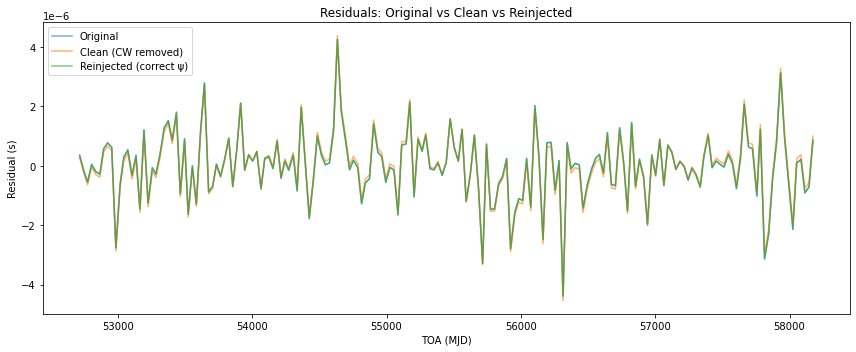

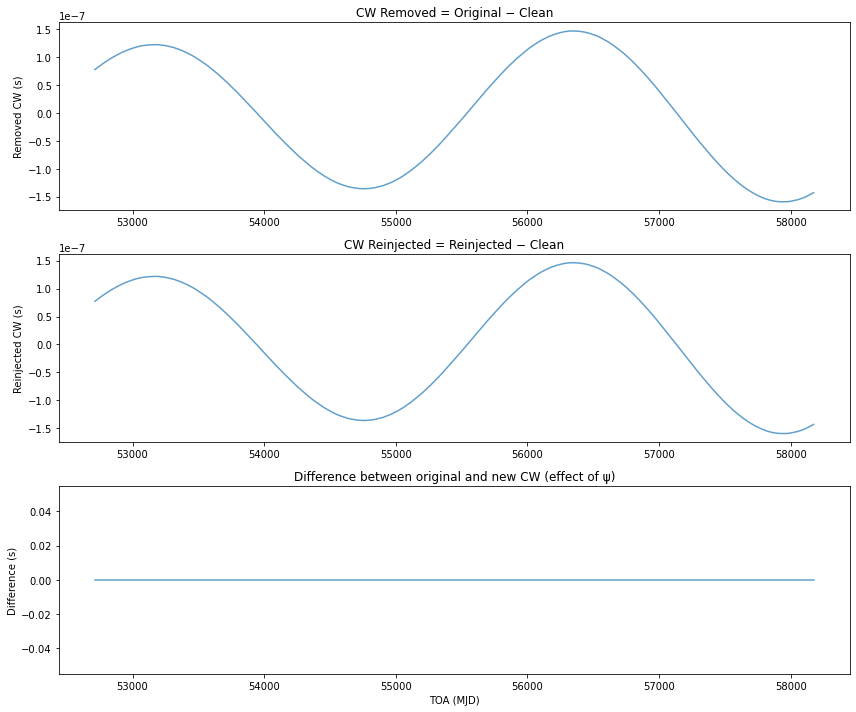

In [13]:
#!/usr/bin/env python3
import libstempo as lt
import matplotlib.pyplot as plt
import numpy as np
import os

#######################################################################
# USER PATHS
#######################################################################

par_original = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/par/J0437-4715.par"
tim_original = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/tim/J0437-4715.tim"

par_clean = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW/J0437-4715.par"
tim_clean = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW/J0437-4715.tim"

par_reinj = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW/J0437-4715.par"
tim_reinj = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW/J0437-4715.tim"


#######################################################################
# LOAD PULSARS
#######################################################################

p_orig = lt.tempopulsar(par_original, tim_original)
p_clean = lt.tempopulsar(par_clean, tim_clean)
p_new = lt.tempopulsar(par_reinj, tim_reinj)

to = p_orig.toas()
ro = p_orig.residuals()
rc = p_clean.residuals()
rn = p_new.residuals()


#######################################################################
# PLOTS
#######################################################################

plt.figure(figsize=(12,5))
plt.plot(to, ro, '-', label="Original", alpha=0.6)
plt.plot(to, rc, '-', label="Clean (CW removed)", alpha=0.6)
plt.plot(to, rn, '-', label="Reinjected (correct ψ)", alpha=0.6)
plt.xlabel("TOA (MJD)")
plt.ylabel("Residual (s)")
plt.title("Residuals: Original vs Clean vs Reinjected")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Difference plots
# ---------------------------------------------------------------------

# Original CW only
cw_removed = ro - rc

# Reinjected CW only
cw_added = rn - rc

# Difference due to old ψ vs new ψ
cw_diff = ro - rn

plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(to, cw_removed, '-', alpha=0.7)
plt.ylabel("Removed CW (s)")
plt.title("CW Removed = Original − Clean")

plt.subplot(3,1,2)
plt.plot(to, cw_added, '-', alpha=0.7)
plt.ylabel("Reinjected CW (s)")
plt.title("CW Reinjected = Reinjected − Clean")

plt.subplot(3,1,3)
plt.plot(to, cw_diff, '-', alpha=0.7)
plt.xlabel("TOA (MJD)")
plt.ylabel("Difference (s)")
plt.title("Difference between original and new CW (effect of ψ)")

plt.tight_layout()
plt.show()


--------------------------------------------------------
CW REMOVAL VERIFICATION RESULTS
--------------------------------------------------------
Max |error|       = 9.892e-08 s
RMS error         = 9.669e-08 s
Correlation(model, diff) = 1.00000
Relative max error       = 7.006e-02
--------------------------------------------------------


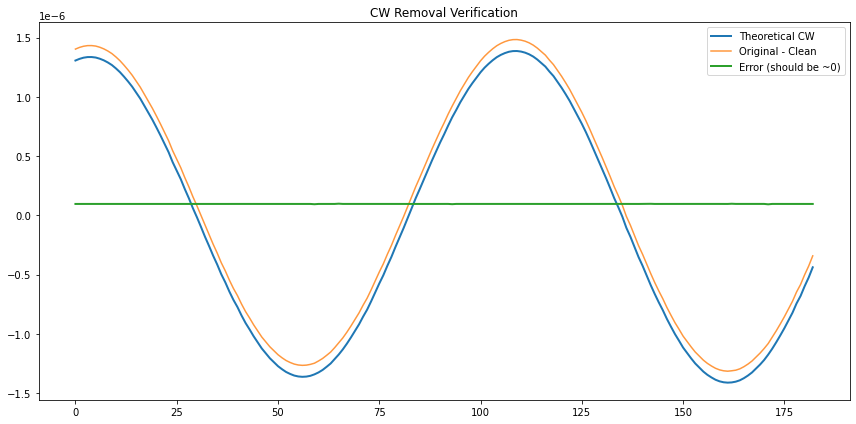

In [6]:
import numpy as np
import libstempo as lt
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# CONSTANTS
# -------------------------------------------------------------
SOLAR2S = 4.925490947e-6
MPC2S   = 1.02927125e14
KPC2S   = 3.085677581e19 / 2.99792458e8
EPS     = np.deg2rad(23.439291111)

def ecl_to_equ(elong, elat):
    lam, beta = elong, elat
    sin_delta = np.sin(beta)*np.cos(EPS) + np.cos(beta)*np.sin(EPS)*np.sin(lam)
    delta = np.arcsin(sin_delta)
    y = np.sin(lam)*np.cos(EPS) - np.tan(beta)*np.sin(EPS)
    x = np.cos(lam)
    alpha = np.arctan2(y, x) % (2*np.pi)
    return alpha, delta

# -------------------------------------------------------------
# CW MODEL
# -------------------------------------------------------------
def cw_residuals(psr, gwtheta, gwphi, mc, dist, fgw, phase0, psi, inc, tref=0.0):

    mc   *= SOLAR2S
    dist *= MPC2S
    w0 = np.pi * fgw
    phase0 /= 2.0
    w053 = w0**(-5/3)

    cosgwtheta, cosgwphi = np.cos(gwtheta), np.cos(gwphi)
    singwtheta, singwphi = np.sin(gwtheta), np.sin(gwphi)

    sin2psi, cos2psi = np.sin(2*psi), np.cos(2*psi)
    incfac1 = 0.5*(3 + np.cos(2*inc))
    incfac2 = 2*np.cos(inc)

    # polarization basis
    m = np.array([singwphi, -cosgwphi, 0.0])
    n = np.array([-cosgwtheta*cosgwphi, -cosgwtheta*singwphi, singwtheta])
    omhat = np.array([-singwtheta*cosgwphi, -singwtheta*singwphi, -cosgwtheta])

    # pulsar position
    if ("RAJ" in psr.pars()) and ("DECJ" in psr.pars()):
        ra, dec = psr["RAJ"].val, psr["DECJ"].val
    else:
        ra, dec = ecl_to_equ(psr["ELONG"].val, psr["ELAT"].val)

    ptheta = np.pi/2 - dec
    pphi   = ra
    phat = np.array([
        np.sin(ptheta)*np.cos(pphi),
        np.sin(ptheta)*np.sin(pphi),
        np.cos(ptheta)
    ])

    fplus  = 0.5*((m@phat)**2 - (n@phat)**2) / (1 + np.dot(omhat, phat))
    fcross =      ((m@phat)*(n@phat))        / (1 + np.dot(omhat, phat))
    cosMu  = -np.dot(omhat, phat)

    # timing
    toas = psr.toas()*86400.0 - tref

    # pulsar-term delay distance (using nominal 1 kpc unless DIST provided)
    if "DIST" in psr.pars() and psr["DIST"].val > 0:
        pd = psr["DIST"].val * KPC2S
    else:
        pd = 1.0 * KPC2S

    tp = toas - pd*(1 - cosMu)

    # chirp evolution
    fac1 = 256/5 * mc**(5/3) * w0**(8/3)
    fac2 = 1/32 / mc**(5/3)

    omega   = w0*(1 - fac1*toas)**(-3/8)
    omega_p = w0*(1 - fac1*tp  )**(-3/8)

    phase   = phase0 + fac2*(w053 - omega  **(-5/3))
    phase_p = phase0 + fac2*(w053 - omega_p**(-5/3))

    At   = np.sin(2*phase  )*incfac1
    Bt   = np.cos(2*phase  )*incfac2
    At_p = np.sin(2*phase_p)*incfac1
    Bt_p = np.cos(2*phase_p)*incfac2

    alpha   = mc**(5/3)/dist/omega  **(1/3)
    alpha_p = mc**(5/3)/dist/omega_p**(1/3)

    rplus   = alpha  *( At  *cos2psi + Bt  *sin2psi)
    rcross  = alpha  *(-At  *sin2psi + Bt  *cos2psi)
    rplus_p = alpha_p*( At_p*cos2psi + Bt_p*sin2psi)
    rcross_p= alpha_p*(-At_p*sin2psi + Bt_p*cos2psi)

    return fplus*(rplus_p - rplus) + fcross*(rcross_p - rcross)

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
par = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/par/J1713+0747.par"
tim_orig = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/tim/J1713+0747.tim"
tim_clean = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW/J1713+0747.tim"

psr_orig = lt.tempopulsar(par, tim_orig)
psr_clean = lt.tempopulsar(par, tim_clean)

ro = psr_orig.residuals()
rc = psr_clean.residuals()

# -------------------------------------------------------------
# THEORETICAL CW MODEL
# -------------------------------------------------------------
gwtheta = 0.6387905062299246
gwphi   = 3.3335788713091694
mc      = 4.3e9
dist    = 75.4
fgw     = 3.7e-9
phase0  = 0.24434609527920614
psi_old = 1.1187560505283651
inc     = 0.8412486994612669
tref    = 55443.93364609394 * 86400

model = cw_residuals(psr_orig, gwtheta, gwphi, mc, dist, fgw,
                      phase0, psi_old, inc, tref=tref)

# -------------------------------------------------------------
# COMPARISON
# -------------------------------------------------------------
diff = ro - rc
err = diff - model

print("--------------------------------------------------------")
print("CW REMOVAL VERIFICATION RESULTS")
print("--------------------------------------------------------")
print(f"Max |error|       = {np.max(np.abs(err)):.3e} s")
print(f"RMS error         = {np.sqrt(np.mean(err**2)):.3e} s")

corr = np.corrcoef(diff, model)[0,1]
print(f"Correlation(model, diff) = {corr:.5f}")

rel = np.max(np.abs(err)) / np.max(np.abs(model))
print(f"Relative max error       = {rel:.3e}")
print("--------------------------------------------------------")

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(model, label="Theoretical CW", lw=2)
plt.plot(diff, label="Original - Clean", alpha=0.8)
plt.plot(err, label="Error (should be ~0)", lw=2)
plt.title("CW Removal Verification")
plt.legend()
plt.tight_layout()
plt.show()


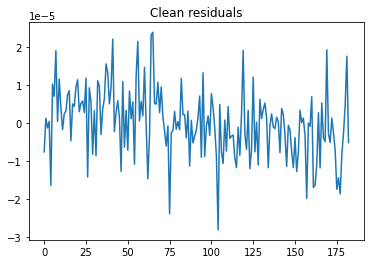

In [8]:
plt.plot(rc, '')
plt.title("Clean residuals")
plt.show()
